# Data Preprocessing Tools

# ============================================================

# SECTION 1

# AI School of India Explanation

Ee section lo data preprocessing concepts ni step-by-step explain chestham — real Melbourne housing dataset tho.

## 1. Imports

Modaluga manaki kavalsina **tools (libraries)** ni import chestunnam. Idi vantalu cheyyadaniki mundu, kavalsina saamanlu (spoons, plates, ingredients) table meeda pettukovadam laantidi.

### Prathi import enduku? (Simple ga)

- **`import pandas as pd`** - CSV/Excel laanti data ni **table (rows and columns)** ga load and handle cheyyadaniki. `pd` ante short name (alias).
- **`import numpy as np`** - **numbers and arrays** tho fast math cheyyadaniki. `np` short name.
- **`from sklearn.model_selection import train_test_split`** - data ni **train set** (nerchukovadaniki) and **test set** (exam laanti check) ga rendu bhagaalu ga split cheyyadaniki.
- **`from sklearn.compose import ColumnTransformer`** - different columns ki different preprocessing (encode okati, scale inkokati) okesari apply cheyyadaniki.
- **`from sklearn.pipeline import Pipeline`** - anni steps (clean, encode, scale, model) ni **oka chain** ga connect cheyyadaniki. Assembly line laantidi.
- **`from sklearn.impute import SimpleImputer`** - **missing values** (khaali cells) ni fill cheyyadaniki (example: average tho).
- **`from sklearn.preprocessing import OneHotEncoder, StandardScaler`**
  - `OneHotEncoder` - text categories (France, Spain) ni **0/1 columns** ga marchadaniki.
  - `StandardScaler` - number columns ni **same scale** lo ki teesukuravadaniki (feature scaling).
- **`from sklearn.linear_model import LinearRegression`** - **prediction model** (straight line fit chesi answer cheppedi).
- **`from sklearn.metrics import mean_squared_error`** - model entha baaga chesindo **error measure** cheyyadaniki (MSE).

### Kid Analogy
- `pandas` = notebook lo table ga raayadam
- `numpy` = calculator
- `train_test_split` = practice papers vs exam papers
- `SimpleImputer` = khaali blank ni average tho fill cheyyadam
- `OneHotEncoder` = names ki number tags pettadam
- `StandardScaler` = anni rulers ni same unit lo pettadam
- `Pipeline` = anni panulu oka line lo chey
- `LinearRegression` = best straight line geesi answer cheppadam

In [199]:
# Step 1: Kavalsina libraries anni import chestunnam (data handling, preprocessing, model, evaluation).
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## 2. Load Dataset (Data ni load cheyyadam)

Ee step lo manam **CSV file** (melb_data.csv) ni open chesi, pandas **DataFrame** (table) loki teesukuntunnam. Idi book open chesi, first page choodadam laantidi - data ela undo ardham cheskovadaniki.

### Prathi line enduku? (Simple ga)

- **`DATA_PATH = "melb_data.csv"`** - file peru (path) ni oka variable lo pettam. Repeat ga type cheyyakunda, oke chota change chesukovachu. Melbourne (Australia) housing data idi.
- **`df = pd.read_csv(DATA_PATH)`** - CSV file ni chadivi **`df`** (DataFrame) loki load chestham. Ippudu data table format lo memory lo untundi.
- **`print("Shape:", df.shape)`** - table size ni chupistundi: **(rows, columns)**. Output `(13580, 21)` ante **13,580 rows** (houses) and **21 columns** (features) unnai ani.
- **`df.head()`** - **modati 5 rows** ni chupistundi. Data ela kanipistundi, column names enti, values ela unnai - quick preview.

### Output ardham
```
Shape: (13580, 21)
```
- **13580** = anni houses (records) count.
- **21** = prathi house gurinchi unna details (columns) - price, rooms, distance, etc.

### Kid Analogy
- `DATA_PATH` = book title raasi pettadam
- `read_csv` = book ni open cheyyadam
- `df.shape` = book lo enni pages (rows) and enni lines per page (columns) unnayo chudadam
- `df.head()` = first page peek chesi story ela undo choodadam

In [200]:
# Step 2: Dataset file path ni variable lo petti, CSV ni DataFrame loki load chesi, shape and first 5 rows chustunnam.
# Dataset file path
DATA_PATH = "melb_data.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## 3. Dataset Info (df.info)

`df.info()` mana dataset gurinchi oka **quick summary report** istundi. Idi doctor **health check-up report** laantidi - prathi column health (type, missing values) okesari chupistundi.

### df.info() emi chupistundi?

- **RangeIndex** - total rows enni unnayo (example: 13580 entries).
- **Total columns** - anni columns count (example: 21 columns).
- **Column name** - prathi column peru.
- **Non-Null Count** - aa column lo **entha values unnayi** (khaali kani cells). Idi total kanna takkuva unte, aa column lo **missing values** unnai ani ardham.
- **Dtype (data type)** - column type: `int64` (whole numbers), `float64` (decimal numbers), `object` (text/strings).
- **memory usage** - dataset RAM lo entha space teesukuntundo.

### Enduku kavali? (Why we need it)

- **Missing values kanukkovadaniki:** Non-Null Count total rows kanna takkuva unte, aa column lo blanks unnai - fill cheyyali.
- **Data types telusukovadaniki:** Ye columns numbers, ye columns text ani telisipotundi. Text columns ni encode cheyyali.
- **Memory ela undo:** Pedda dataset aithe memory usage chudadam help avutundi.

### Kid Analogy
- `df.info()` = class attendance sheet + report card okesari chudadam
- Non-Null Count = evaru present unnaro (blanks = absent students)
- Dtype = prathi subject type (numbers subject vs language subject)

In [201]:
# Step 3: Dataset summary (rows count, column types, non-null counts, memory) ni chudataniki df.info() call chestunnam.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

# Data Cleaning - Different Types (Detailed with Examples)

Data cleaning ante mana **raw data lo unna problems** (mistakes, blanks, duplicates, wrong values) ni fix chesi, data ni **clean and correct** ga marchadam. Model ki edaina nerpinchadaniki mundu idi chala mukhyam.

> **Golden Rule:** "Garbage In, Garbage Out." Data dirty ga unte, model kuda tappu nerchukuntundi. Anduke first data ni clean cheyyali.

Kid analogy: **kayagaralu (vegetables)** konnappudu - konni cheddaipoyi (rotten), konni duplicate, konni sarigga wash cheyyali, konni wrong basket lo untai. Vantalu (cooking = model training) mundu vaatini clean chesukovali. Ade data cleaning.

Kinda **different types of data cleaning** ni examples tho detail ga chuddam.

---

## 1. Handling Missing Values (Khaali cells fix cheyyadam)

**Problem:** Konni cells lo value undadu (blank / NaN). Example: oka person `Age` fill cheyyaledu.

**Enduku problem:** Model ki `NaN` (empty) ardham kaadu, calculations fail avtai.

**Ela fix cheyyali (options):**
- **Remove (drop):** Missing unna rows/columns ni teesesi.
- **Fill (impute):** Missing place lo oka reasonable value pettadam (mean, median, mode, or fixed value).

**Example (pandas):**
```python
# Missing values enni unnayo check
df.isnull().sum()

# Option A: missing unna rows drop cheyyadam
df.dropna(inplace=True)

# Option B: numeric column ni mean tho fill
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Option C: text column ni mode (most common) tho fill
df['Country'].fillna(df['Country'].mode()[0], inplace=True)
```

**Eppudu edi vadali:**
- Missing chala takkuva (5% lopu) -> drop cheyyachu.
- Numeric column, normal data -> **mean**.
- Numeric column, outliers unte -> **median** (safer).
- Text/category column -> **mode** (most frequent).

---

## 2. Removing Duplicate Rows (Duplicate rows teesesi)

**Problem:** Same row do sarlu (or ekkuva) data lo unte. Example: oke customer record 2 sarlu enter aindi.

**Enduku problem:** Duplicates valla model biased avtundi (oka record ki extra weight vastundi), stats kuda tappu vastai.

**Example (pandas):**
```python
# Enni duplicate rows unnayo
df.duplicated().sum()

# Duplicates ni remove cheyyadam (first occurrence unchi)
df.drop_duplicates(inplace=True)
```

**Tip:** Konni sarlu specific columns batti duplicate decide cheyyali:
```python
df.drop_duplicates(subset=['Name', 'Email'], keep='first', inplace=True)
```

---

## 3. Handling Outliers (Extreme / abnormal values)

**Problem:** Migatha values kanna chala pedda or chala chinna value. Example: anni salaries 30k-90k, kani oka value 99,00,000.

**Enduku problem:** Outliers valla mean, scaling, model anni distort avtai (especially Linear Regression, KNN).

**Ela detect cheyyali:**
- **describe()** lo min/max chudadam.
- **IQR method:** Q1, Q3 use chesi range ki bayata unna values.
- **Boxplot** graph.

**Example (IQR method):**
```python
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

# Outliers ni remove cheyyadam (range lopu unna rows matrame unchadam)
df = df[(df['Salary'] >= low) & (df['Salary'] <= high)]
```

**Options:** remove cheyyadam, cap/clip cheyyadam (limit ki set), or transform (log) cheyyadam.

## 4. Fixing Data Types (Wrong type ni correct type ki marchadam)

**Problem:** Column type tappu ga undadam. Example: `Age` numbers, kani text (`object`) ga store aindi; or date column text ga undadam.

**Enduku problem:** Numbers meeda math cheyyalem text ga unte; dates meeda date operations cheyyalem.

**Example (pandas):**
```python
# Text laaga unna number column ni number ki marchadam
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Text date ni real datetime ki marchadam
df['JoinDate'] = pd.to_datetime(df['JoinDate'])

# Category column ni 'category' type ki (memory save)
df['Country'] = df['Country'].astype('category')
```

`errors='coerce'` ante convert kaani values ni `NaN` ga marchi, aa tarvata missing-value handling apply cheyyachu.

---

## 5. Fixing Inconsistent Text / Formatting (Text ni standardize cheyyadam)

**Problem:** Oke value different ga raayadam. Example: `India`, `india`, ` INDIA `, `Indan` (typo). Model vaatini different categories ga anukuntundi.

**Common issues:** extra spaces, different case (upper/lower), spelling mistakes.

**Example (pandas):**
```python
# Extra spaces teesi, anni lowercase ki
df['Country'] = df['Country'].str.strip().str.lower()

# Spelling / value mapping tho fix
df['Country'] = df['Country'].replace({'indan': 'india', 'inda': 'india'})

# Title case (first letter capital)
df['Name'] = df['Name'].str.title()
```

---

## 6. Handling Invalid / Wrong Values (Logic ki virudham values)

**Problem:** Value technically number, kani **logically wrong**. Example: `Age = -5`, `Age = 999`, or `Price = 0` (impossible).

**Example (pandas):**
```python
# Negative age ni invalid ga treat chesi NaN ga marchadam
df.loc[df['Age'] < 0, 'Age'] = np.nan

# Impossible high age ni cap cheyyadam
df.loc[df['Age'] > 120, 'Age'] = np.nan

# Aa tarvata missing-value strategy tho fill
df['Age'].fillna(df['Age'].median(), inplace=True)
```

## 7. Removing Irrelevant / Unnecessary Columns (Avasaram lekunda columns teesadam)

**Problem:** Konni columns model ki help cheyyavu. Example: `ID`, `Row Number`, or fully empty column.

**Enduku:** Unnecessary columns noise add chesi, model ni confuse chestai and slow chestai.

**Example (pandas):**
```python
# Avasaram lekunda columns ni drop cheyyadam
df.drop(columns=['CustomerID', 'RowNumber'], inplace=True)
```

**Jagratha:** Domain knowledge tho decide cheyyali - useful column porapatuna drop cheyyakudadu.

---

## 8. Handling Structural / Categorical Errors (Category typos, wrong labels)

**Problem:** Same category ni different spellings/labels tho raayadam. Example: `Male`, `M`, `male`, `MALE` anni oke thing kani model different ga chustundi.

**Example (pandas):**
```python
# Anni variants ni oke standard value ki map cheyyadam
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Gender'] = df['Gender'].replace({'m': 'male', 'f': 'female'})

# Unique values check chesi inka errors unnaya chudadam
print(df['Gender'].unique())
```

---

## 9. Handling Noisy Data (Random errors / meaningless values)

**Problem:** Random errors, garbage values, or sensor errors. Example: temperature column lo `#N/A`, `???`, or random symbols.

**Example (pandas):**
```python
# Garbage values ni NaN ga marchi, aa tarvata handle cheyyadam
df['Temp'] = df['Temp'].replace(['#N/A', '???', 'error'], np.nan)
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')
```

## Data Cleaning Full Flow (Order)

```mermaid
flowchart TD
    A[Raw Dirty Data] --> B[Missing Values fix]
    B --> C[Duplicates remove]
    C --> D[Wrong Data Types fix]
    D --> E[Text/Format standardize]
    E --> F[Invalid values fix]
    F --> G[Outliers handle]
    G --> H[Irrelevant columns drop]
    H --> I[Clean Data - ML Ready]
```

## Cheat Sheet (quick gurthu)

| Type | Problem | Common Fix |
|------|---------|-----------|
| Missing values | blank / NaN cells | dropna / fillna (mean, median, mode) |
| Duplicates | same row repeat | drop_duplicates() |
| Outliers | extreme values | IQR remove / clip / log |
| Wrong data type | number as text, date as text | to_numeric / to_datetime / astype |
| Inconsistent text | case, spaces, typos | str.strip / str.lower / replace |
| Invalid values | age = -5, price = 0 | condition tho NaN + fill |
| Irrelevant columns | ID, row number | drop(columns=...) |
| Category errors | M / male / MALE | replace + standardize |
| Noisy data | ???, #N/A, garbage | replace to NaN + coerce |

**Final gurthu:** Data cleaning oke sari cheyyadu - **iterative** process. Clean chesi, malli `df.info()` and `df.describe()` tho check chesi, inka problems unte malli fix cheyyali. Clean data = better model.

## 4. Describe (df.describe)

`df.describe()` **number columns** ki oka **statistics summary** istundi. Idi class lo marks report laantidi - average marks entha, highest entha, lowest entha, anni okesari chupistundi.

### df.describe() emi chupistundi? (prathi row ardham)

- **count** - aa column lo entha values (non-null) unnayo. Missing unte count takkuva untundi.
- **mean** - average value (anni add chesi count tho divide chesindi).
- **std** - standard deviation. Values average nunchi entha spread (chelaachedi) unnayo cheppedi. Chinna std = values close, pedda std = values chala spread.
- **min** - aa column lo smallest value.
- **25% (Q1)** - first quartile. Data ni sort chesthe 25% values ee value kanna takkuva.
- **50% (median)** - middle value. Sort chesthe sarigga madhya value. (Outliers unte mean kanna median better.)
- **75% (Q3)** - third quartile. 75% values ee value kanna takkuva.
- **max** - aa column lo largest value.

### Enduku kavali? (Why we need it)

- **Range telusukovadaniki:** min and max chusi values ye range lo unnayo telustundi (example: Age 0 nunchi 100).
- **Outliers kanukkovadaniki:** max chala pedda ga (mean kanna) unte, adi outlier avvachu (example: price lo oka house 100 crores).
- **Scaling avasarama ani decide cheyyadaniki:** Different columns ranges chala different ga unte (Age 20-50, Salary 30000-90000), scaling kavali ani ardham avutundi.
- **mean vs median compare:** Rendu chala different unte, data **skewed** (oka vaipuki lean) ani ardham.

### Extra tip
- Default ga `df.describe()` **numeric columns matrame** chupistundi.
- Text columns kuda kavali ante: `df.describe(include='all')` vaadatam.

### Kid Analogy
- `df.describe()` = class marks summary sheet
- mean = class average marks
- min/max = lowest and highest marks
- std = marks anni close ga unnaya leda chala spread unnaya
- 25%/50%/75% = class ni ranks prakaram divide chesi middle points chudadam

In [202]:
# Step 4: Numeric columns ki statistics summary (count, mean, std, min, quartiles, max) chudataniki df.describe() call chestunnam.
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


## 5. Split into X (Features) and y (Target)

Ee step lo manam data ni **rendu bhagaalu** ga divide chestunnam:
- **`y` (Target)** - manam predict cheyyali anukune answer column (ikada `Price`).
- **`X` (Features)** - migatha anni columns (inputs), vaati batti `y` ni predict chestham.

Idi **question paper (X)** and **answer key (y)** separate cheyyadam laantidi. Model `X` chusi `y` guess cheyyadam nerchukuntundi.

### Prathi line enduku? (Simple ga)

- **`y = df['Price']`** - `Price` column ni target `y` ga teesukuntunnam. Idi mana house price prediction goal.
- **`X = df.drop(columns=['Price'])`** - `Price` column ni **teesesi** migatha anni columns ni features `X` ga tiskuntunnam. `drop` valla original `df` lo Price kaakunda, X lo migatha data untundi.
- **`X.head(2)`** - X lo **modati 2 rows** chupistundi - features correct ga vachaya, Price column poyinda ani verify cheyyadaniki.

### Enduku Price ni drop chestam?
- Price ne manam predict cheyyali (answer). Adi features lo unte, model **cheating** chesinatte (answer already chusi cheppadam). Anduke X nunchi target ni teesesi, matrame inputs unchutham.

### Kid Analogy
- `y` = exam answer key (Price)
- `X` = question paper (migatha details: rooms, distance, etc.)
- `drop` = answer key ni question paper nunchi teesesi separate pettadam
- `X.head(2)` = question paper first 2 questions peek chesi correct ga unda ani chudadam

In [203]:
# Step 5: Price column ni target (y) ga, migatha columns ni features (X) ga separate chestunnam.
# Target
y = df['Price']

# Features
X = df.drop(columns=['Price'])

In [204]:
# Step 6: Features (X) first 2 rows chusi, Price teesesaka data correct ga unda ani verify chestunnam.
X.head(2)

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0


## 6. Drop Unnecessary Columns (Avasaram lekunda columns teesadam)

Ee step lo manam `X` (features) nunchi **model ki help cheyyani columns** ni teesestunnam. Idi mundu chepina **Data Cleaning - Type 7 (Irrelevant Columns)** ni real ga apply cheyyadam.

### Enduku ee columns drop chestunnam?

- **`Address`** - prathi house ki unique text address. Idi model ki pattern ivvadu (13580 different values), just noise. Anduke teesestham.
- **`Propertycount`** - suburb level count, target (Price) ki direct ga help cheyyadu ee example lo.
- **`Lattitude`, `Longtitude`** - GPS coordinates. Advanced models lo use avvachu, kani ee simple example lo teesestunnam (Suburb, Distance already location idea istai).

### Prathi line enduku? (Simple ga)

- **`X.drop(columns=['Address', 'Propertycount'], inplace=True)`**
  - `columns=[...]` - ye columns teeyalo list.
  - `inplace=True` - original `X` lone change cheyyi (kotha variable avasaram ledu). `inplace=False` aithe copy istundi, X marchadu.
- **`X.drop(columns=['Lattitude', 'Longtitude'], inplace=True)`** - ade laaga latitude/longitude columns teesestunnam.
- **`X.columns`** - ippudu `X` lo migilina column names list ni chupistundi - correct columns matrame unnaya ani verify.

> **Important (axis enduku vaddu):** `columns=[...]` isthe `axis=1` **avasaram ledu**. Rendu okesari (`columns=...` and `axis=1`) isthe pandas `ValueError: Cannot specify both 'axis' and 'index'/'columns'` throw chestundi. So `columns=` vadutunnappudu axis vadakandi. (Alternative: `X.drop(['Address', 'Propertycount'], axis=1, inplace=True)` - ikada column names ni positional ga isthe axis=1 kavali.)

> **Note:** Ee dataset lo column names spelling `Lattitude` and `Longtitude` (double 't') - original CSV lo alane unnai, kabatti ade spelling vadali, lekapothe `KeyError` vastundi.

### Kid Analogy
- `X` = school bag lo anni books
- `drop` = avasaram lekunda books (Address, GPS) ni bag nunchi teeyadam
- `inplace=True` = ade bag lo teesesi, kotha bag teesukokunda
- `X.columns` = bag lo ippudu ye books unnayo list chesukovadam

In [205]:
# Step 7: Address and Propertycount columns ni X nunchi teesestunnam (model ki useful kaadu).
X.drop(columns=['Address', 'Propertycount'], inplace=True)

In [206]:
# Step 8: Lattitude and Longtitude (GPS) columns ni kuda X nunchi teesestunnam.
X.drop(columns=['Lattitude', 'Longtitude'], inplace=True)

In [207]:
# Step 9: Migilina feature columns ni chusi, unnecessary columns poyaya ani verify chestunnam.
X.columns

Index(['Suburb', 'Rooms', 'Type', 'Method', 'SellerG', 'Date', 'Distance',
       'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
       'YearBuilt', 'CouncilArea', 'Regionname'],
      dtype='str')

## 7. Feature Engineering (Date -> Year / Month / Day)

Ikada manam **oke `Date` column nunchi kotha useful columns** create chestunnam. Deenini **Feature Engineering** antaru - unna data nunchi model ki ekkuva meaning unna features tayaru cheyyadam.

### Enduku ee step?

- `Date` (example: `3/12/2016`) oka **text/date** laaga untundi. Model ki direct ga "date" ardam kaadu.
- Kani date lo daagi unna **useful signals** unnai: ye **year** lo ammaru, ye **month** (season effect), ye **day**. Ee chinna pieces model ki pattern nerchukovadaniki help chestai.
- So manam pedda date ni chinna chinna numbers (Year, Month, Day) ga break chestunnam.

### Prathi line enduku? (Simple ga)

- **`pd.to_datetime(X['Date'], errors="coerce", dayfirst=True)`**
  - `pd.to_datetime(...)` - text ni real **datetime** type ga marchutundi.
  - `dayfirst=True` - date format `day/month/year` (Australian style) ani cheptundi, so `3/12/2016` = 3rd December.
  - `errors="coerce"` - convert avvani wrong date unte, crash avvakunda daanini `NaT` (missing) ga pedatundi.
- **`.dt.year` / `.dt.month` / `.dt.day`** - datetime nunchi year, month, day numbers ni teestundi. Kotha columns `SoldYear`, `SoldMonth`, `SoldDay` lo store chestunnam.
- **`X.drop(columns=['Date'], inplace=True)`** - useful info already extract chesam, so raw `Date` column ni ippudu teesestunnam (avasaram ledu).

### Kid Analogy
- `Date` = oka full sentence "3 December 2016 na ammaru"
- Feature engineering = aa sentence nunchi 3 chinna cards teeyadam: **Year card (2016)**, **Month card (12)**, **Day card (3)**
- Model ki full sentence kanna ee chinna cards easy ga ardam avutai
- Chivara raw `Date` ni teesestham - cards already teesukunnam kabatti

> **Note:** `SoldMonth` chala important - real estate lo month/season prices ni effect chestundi (example: summer lo ekkuva sales).


In [208]:
# Step 10: Date column ni datetime ga marchi, year/month/day ni kotha columns ga teesestunnam.
X['Date'] = pd.to_datetime(X['Date'], errors="coerce", dayfirst=True)
X['SoldYear'] = X['Date'].dt.year
X['SoldMonth'] = X['Date'].dt.month
X['SoldDay'] = X['Date'].dt.day

# Features extract chesaka raw Date column ni teesestunnam (ippudu avasaram ledu).
X.drop(columns=['Date'], inplace=True)


In [209]:
# Step 11: Feature engineering taruvata X ni check chestunnam - Date poyi SoldYear/SoldMonth/SoldDay vachaya ani.
X.head()


,Suburb,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Regionname,SoldYear,SoldMonth,SoldDay
0,Abbotsford,2,h,S,Biggin,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,Northern Metropolitan,2016,12,3
1,Abbotsford,2,h,S,Biggin,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,Northern Metropolitan,2016,2,4
2,Abbotsford,3,h,SP,Biggin,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,Northern Metropolitan,2017,3,4
3,Abbotsford,3,h,PI,Biggin,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,Northern Metropolitan,2017,3,4
4,Abbotsford,4,h,VB,Nelson,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,Northern Metropolitan,2016,6,4


## 8. Numeric vs Categorical Columns Separate Cheyyadam

Ikada manam `X` lo unna columns ni **rendu groups** ga separate chestunnam:
- **Numeric columns** - numbers unna columns (Rooms, Distance, Landsize, SoldYear...).
- **Categorical columns** - text/category unna columns (Suburb, Type, Method, CouncilArea...).

### Enduku ee separation?

- Numbers and text ni model ki **verega treat** cheyyali.
  - Numbers ki - missing fill (mean), scaling laanti pani cheyyali.
  - Text/category ki - encoding (One-Hot, Label) cheyyali, enduku ante model ki numbers matrame ardam avutai.
- So mundu ye columns numeric, ye columns categorical ani teliste, taruvata prathi group ki correct preprocessing apply cheyyachu.

### Prathi line enduku? (Simple ga)

- **`X.select_dtypes(include="number")`** - `X` nunchi **numbers unna columns matrame** teestundi. Deenini `num_X` lo pedatunnam.
  - `include="number"` - int, float laanti number types ni teesuko ani cheptundi.
- **`X.select_dtypes(exclude="number")`** - **numbers KAADU** unna columns (ante text/object/category) ni teestundi. Deenini `cat_X` lo pedatunnam.
  - `exclude="number"` - numbers ni vadili migilinavi (text) teesuko.

### Kid Analogy
- `X` = oka pedda mixed box lo bommalu (numbers) and cards (text)
- `select_dtypes(include="number")` = box lo nunchi **bommalu matrame** oka basket lo veyadam (`num_X`)
- `select_dtypes(exclude="number")` = migilina **cards ni** vere basket lo veyadam (`cat_X`)
- Ippudu rendu baskets separate - each ki different pani cheyyachu

> **Note:** Ee two lists taruvata `ColumnTransformer`/`Pipeline` lo use avutai - numeric ki oka treatment, categorical ki inkoka treatment. Anduke ippude separate chesukuntunnam.


In [210]:
# Step 12: X ni numeric and categorical columns ga separate chestunnam.
num_X = X.select_dtypes(include="number")
cat_X = X.select_dtypes(exclude="number")


# 9. Feature Scaling (Anni columns ni oke range loki teesuku raadam)

## Scaling ante enti? (Simple ga)

Manaki data lo different columns unnai, kani vaati **units and range totally different** ga untai:

| Column | Values example | Range (size) |
|--------|----------------|--------------|
| `Sqft` (area) | 1000, 2500, 4000 | **thousands** lo |
| `Rooms` | 2, 3, 5 | **units / tens** lo |

Sqft numbers (thousands) chala **peddavi**, Rooms numbers (units) chala **chinnavi**. Model ki ee rendu numbers direct ga isthe, model anukuntundi "Sqft chala important, enduku ante daani numbers peddavi" - kani adi **wrong**. Number pedda ga undadam valla adi important kaadu, adi just **different unit** valla.

**Scaling** = anni columns ni **oke common range loki** teesuku raadam (example: `0 to 1` or `-1 to 1`). Appudu prathi column **fair ga** compare avutundi, e column dominate cheyyadu.

```
Sqft (thousands)  ----\
                        >--- [ Single Scale ] ---> 0 to 1   (or)   -1 to 1
Rooms (units/tens)----/
```

### Kid Analogy
- Oka race lo okaru **kilometers** lo, inkokaru **meters** lo running cheptunnaru anuko - compare cheyyadam kastam.
- Scaling = andarini **oke unit** loki marchadam, appudu evaru fast ga unnaro fair ga telustundi.
- Number pedda ga undadam != important. Unit same cheyyadam matrame fair.

---

## Enduku scaling avasaram? (Why it matters)

1. **Distance-based models** (KNN, K-Means, SVM) - ivi points madhya distance calculate chestai. Pedda range column distance ni dominate chestundi, so scaling **must**.
2. **Gradient Descent models** (Linear/Logistic Regression, Neural Networks) - scaled data tho **faster and stable** ga converge avutai (learning easy).
3. **Regularization** (Ridge, Lasso) - anni features same scale lo unte penalty fair ga apply avutundi.

> **Note:** **Tree-based models** (Decision Tree, Random Forest, XGBoost) ki scaling **avasaram ledu** - avi splits base chesukuntayi, range effect cheyyadu.

---

## Enni types of Scaling unnai? (Main 4 types)

### 1. Min-Max Scaling (Normalization) -> `MinMaxScaler`
Anni values ni fixed range **[0, 1]** (or [-1, 1]) loki teestundi.

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

- **Result range:** 0 to 1 (default).
- **Eppudu vadali:** range fixed kavali aninappudu, data lo pedda outliers lekapothe. Image pixels, neural networks ki manchidi.
- **Problem:** outlier unte (oka chala pedda value), migilina anni values chinna range loki nalagipotai.

### 2. Standardization (Z-score) -> `StandardScaler`
Values ni **mean = 0**, **standard deviation = 1** loki marchutundi.

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

($\mu$ = mean/average, $\sigma$ = standard deviation)

- **Result range:** fixed kaadu (mostly -3 to +3 madhya), mean 0 chuttu untundi.
- **Eppudu vadali:** most common choice. Data roughly **normal (bell curve)** ga unnappudu, and Linear Regression / Logistic / SVM / Neural Nets ki best.
- Ee notebook lo already `StandardScaler` (`sc`) vaadam - adi ee type.

### 3. Robust Scaling -> `RobustScaler`
Median and IQR (Inter-Quartile Range) vaadi scale chestundi.

$$X_{scaled} = \frac{X - median}{IQR}$$

- **Eppudu vadali:** data lo **outliers ekkuva** unnappudu. Median and IQR outliers valla effect avvavu, so robust (strong).

### 4. MaxAbs Scaling -> `MaxAbsScaler`
Prathi value ni aa column max absolute value tho divide chestundi. Range **[-1, 1]**.

$$X_{scaled} = \frac{X}{|X_{max}|}$$

- **Eppudu vadali:** **sparse data** (chala zeros unna data, example text TF-IDF) ki - adi zeros ni disturb cheyyadu.

---

## Cheat Sheet (Ekkada edi vadali)

| Scaler | Output range | Best for | Outliers ni handle chestunda? |
|--------|--------------|----------|-------------------------------|
| `MinMaxScaler` | 0 to 1 | pixels, NN, fixed range | No (weak) |
| `StandardScaler` | mean 0, std 1 | most ML models (default) | Somewhat |
| `RobustScaler` | median center | outliers ekkuva unnappudu | Yes (strong) |
| `MaxAbsScaler` | -1 to 1 | sparse data (text/TF-IDF) | No |

---

## Mukhyamaina 3 Rules (Very Important)

1. **Fit on train, transform on both:** `scaler.fit(X_train)` matrame chey, taruvata `X_train` and `X_test` rendintini `transform` chey. Test data meeda `fit` cheste **data leakage** avutundi (cheating).
2. **Numeric columns matrame scale chey:** categorical (text) columns ni scale cheyyakudadu - mundu encode chey, taruvata numeric matrame scale chey. (Anduke manam mundu `num_X`, `cat_X` separate chesam.)
3. **Target (y) ni normal ga scale cheyyaku** classification lo. Regression lo konnisarlu chestaru, kani careful ga.

> **Summary:** Normalization (MinMax) = fixed range [0,1]. Standardization (Z-score) = mean 0, std 1. Outliers unte Robust. Sparse aithe MaxAbs. Default doubt aithe -> `StandardScaler`.


# 10. One-Hot Encoding (Categorical text ni numbers ga marchadam)

## One-Hot Encoding ante enti? (Simple ga)

Model ki **text ardam kaadu, numbers matrame** ardam avutai. Kani manaki `Region` laanti **categorical (text) columns** untai (Hyd, Chennai, Bangalore...). Vaatini numbers ga marchali - deenike **encoding** antaru.

**One-Hot Encoding** = prathi category ki oka **separate column** (0/1 flag) create cheyyadam. Aa row lo aa category unte `1`, lekapothe `0`.

### Example (mee diagram laaga)

**Before (oke Region column):**

| Region |
|--------|
| Hyd |
| Chennai |
| Bangalore |
| Hyd |
| Chennai |

**After One-Hot Encoding (3 kotha columns):**

| Region_Hyd | Region_Bangalore | Region_Chennai |
|:---:|:---:|:---:|
| 1 | 0 | 0 |
| 0 | 0 | 1 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 0 | 0 | 1 |

- Row 1 Hyd -> `Region_Hyd = 1`, migilinavi 0.
- Row 3 Bangalore -> `Region_Bangalore = 1`, migilinavi 0.
- Prathi row lo **oka column matrame 1** (anduke peru "one-hot").

---

## Enduku One-Hot? Enduku just 1,2,3 numbers ivvakudadu?

Manam Hyd=1, Chennai=2, Bangalore=3 ani simple numbers isthe (Label Encoding), model anukuntundi **Bangalore(3) > Chennai(2) > Hyd(1)** ani - ante oka **order/ranking** undi ani. Kani cities ki order ledu! Idi model ni confuse chestundi.

One-Hot lo anni categories **equal** (0/1 flags), e ranking ledu. Anduke **nominal categories** (order lekunda unna text: cities, colors, gender) ki One-Hot best.

---

## Prathi line enduku? (pandas `get_dummies`)

- **`pd.get_dummies(df, columns=['Region'])`** - `Region` column ni teesi, prathi unique value ki oka 0/1 column create chestundi (`Region_Hyd`, `Region_Chennai`, `Region_Bangalore`).
- **`drop_first=True`** - modati category column ni teesestundi (n categories ki n-1 columns). Idi **dummy variable trap** (columns okadaniki okati perfectly related avvadam) ni avoid chestundi. Example: Hyd, Bangalore telisthe Chennai automatic ga telustundi.
- **`dtype=int`** - output ni `True/False` badulu `1/0` numbers ga istundi.

### Kid Analogy
- `Region` column = oka box lo city name cards (Hyd, Chennai...)
- One-Hot = prathi city ki oka **separate on/off switch** (bulb) pettadam
- Aa row city ki matching bulb `ON (1)`, migilinavi `OFF (0)`
- Numbers 1,2,3 isthe "Bangalore is bigger than Hyd" ani model anukuntundi - adi tappu, anduke switches (0/1) vadatam

> **Note:** One-Hot valla columns count perugutundi (chala unique categories unte chala columns vastai = "high cardinality"). Alaanti time lo One-Hot badulu Target/Frequency encoding laanti methods vadataru.

> **sklearn lo:** `OneHotEncoder` (already import chesam) `ColumnTransformer` tho use chestaru - Pipeline lo clean ga fit avutundi.


In [211]:
# Step 13: One-Hot Encoding demo - oka chinna Region example tho ela pani chestundo chudadam.
demo = pd.DataFrame({'Region': ['Hyd', 'Chennai', 'Bangalore', 'Hyd', 'Chennai']})

# get_dummies tho Region ni 0/1 columns ga marchutunnam.
demo_encoded = pd.get_dummies(demo, columns=['Region'], dtype=int)
demo_encoded


,Region_Bangalore,Region_Chennai,Region_Hyd
0,0,0,1
1,0,1,0
2,1,0,0
3,0,0,1
4,0,1,0


# 11. Preprocessing Pipeline (Impute + Encode + Scale okate chain lo)

## Idi enti? (Simple ga)

Ippati varaku manam different cleaning steps (missing fill, scaling, one-hot encoding) separate ga nerchukunnam. Ikada vaatini anni **oka automatic chain (Pipeline)** ga connect chestunnam. Ala chesthe:

- Prathi step ni manam manually cheyyanavasaram ledu - chain ki data isthe, anni steps order lo run avutai.
- **Data leakage** raadu - `fit` train meeda matrame jarugutundi.
- Kotha data vachina, same chain apply cheste chaalu (reusable).

Manaki data lo **rendu rakala columns** unnai, so **rendu different pipelines** kavali:
- **Numeric columns** (num_X) -> missing fill (median) + scaling.
- **Categorical columns** (cat_X) -> missing fill (most_frequent) + one-hot encode.

---

## Part A: Numeric Pipeline (`num_transformations`)

- **`SimpleImputer(strategy="median")`** - numeric columns lo missing (NaN) unte, aa column **median** (middle value) tho fill chestundi. Median vadatam valla outliers effect avvavu.
- **`StandardScaler()`** - taruvata anni numbers ni same scale (mean 0, std 1) loki teestundi.
- `Pipeline(steps=[...])` - ee rendu steps ni **order lo** (mundu impute, taruvata scale) run cheyyadaniki chain chestundi.

## Part B: Categorical Pipeline (`cat_transformations`)

- **`SimpleImputer(strategy="most_frequent")`** - text columns lo missing unte, aa column lo **most common value** (mode) tho fill chestundi.
- **`OneHotEncoder(handle_unknown="ignore")`** - text categories ni 0/1 columns ga marchutundi.
  - `handle_unknown="ignore"` - test/kotha data lo **train lo leni kotha category** vasthe, crash avvakunda daanini anni-zeros ga treat chestundi. Chala important safety.

---

## Part C: ColumnTransformer (rendu pipelines ni combine)

- **`ColumnTransformer(transformers=[...])`** - ye columns ki ye pipeline apply cheyyalo cheptundi:
  - `("num", num_transformations, num_X.columns)` - **numeric columns** ki numeric pipeline.
  - `("cat", cat_transformations, cat_X.columns)` - **categorical columns** ki categorical pipeline.
- **`remainder="drop"`** - pai rendu lists lo leni migilina columns unte, vaatini **teesestundi** (drop). (`remainder="passthrough"` isthe as-is unchutundi.)

### Kid Analogy
- `Pipeline` = washing machine lo steps chain (wash -> rinse -> dry) - okate button, anni order lo jarugutai
- Numeric pipeline = numbers ki oka machine (fill + scale)
- Categorical pipeline = text ki vere machine (fill + encode)
- `ColumnTransformer` = oka manager - "ee columns aa machine ki, aa columns ee machine ki" ani route chestadu
- `remainder="drop"` = evaru list lo lero, vaallani pampinchesadam (drop)

> **Note:** Ikada manam pipeline ni **define** matrame chestunnam (blueprint). Actual ga data transform avvaledu inka - adi taruvata `fit`/`fit_transform` (or model tho kalipi) call chesinappudu jarugutundi.


In [212]:
# Step 14: Numeric ki pipeline (median impute + scale), Categorical ki pipeline (most_frequent impute + one-hot encode).
# Numeric: median impute + scale
num_transformations = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaling", StandardScaler()),
])

# Categorical: most_frequent impute + one-hot encode
cat_transformations = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])


In [213]:
# Step 15: Rendu pipelines ni ColumnTransformer tho combine - num columns ki okati, cat columns ki inkokati.
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformations, num_X.columns),
    ("cat", cat_transformations, cat_X.columns),
], remainder="drop")

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 12. Train-Test Split (Data ni train and test ga divide cheyyadam)

## Train-Test Split ante enti? (Simple ga)

Machine learning lo model train cheyyadaniki data kavali, kani model actually **new, unseen data** meeda ela perform chestundo kuda test cheyyali. Anduke manam data ni **rendu parts** ga split chestham:

- **Training Set (X_train, y_train):** Model idi chusi nerchukkuntundi. Idi "classroom lo study" laantidi.
- **Test Set (X_test, y_test):** Model idi mundu chudadu — idi real-world performance ki "final exam" laantidi.

```
Full Dataset (100%)
      |
      |-- Train Set (85%) --> Model nerchukovadam
      |-- Test Set  (15%) --> Model evaluate cheyyadam
```

---

## `test_size` ante enti?

- Total data lo **entha % test ki** pettalo cheppe parameter.
- `test_size=0.15` ante **15% test ki**, migilina **85% train ki**.
- Screenshot lo `X_test.shape` output `(2037, 18)` — adi 15% rows test set lo unnai ani chupistundi.

| `test_size` | Train % | Test % |
|:-----------:|:-------:|:------:|
| 0.10 | 90% | 10% |
| 0.15 | 85% | 15% |
| 0.20 | 80% | 20% |
| 0.25 | 75% | 25% |

---

## `random_state` enduku vadali?

- `train_test_split` rows ni **randomly shuffle** chesi split chestundi.
- `random_state` value fix chesthe, prathi run lo **same shuffle → same split** vastundi (**reproducibility**).
- `random_state` lekapothe, prathi run ki different rows test/train ki veluthai — compare chestukunnapudu confusing.

```python
# random_state lekapothe — different split prathi sari
train_test_split(X, y, test_size=0.15)

# random_state=42 — anni runs lo same split
train_test_split(X, y, test_size=0.15, random_state=42)
```

> **Gurthu:** `random_state` value (42 aina, 1 aina) result quality marchadu — just "which fixed shuffle" lock chestundi.

---

## Enduku Split BEFORE Preprocessing kaadu?

Manam ikkad **Pipeline tho preprocessing** chestunnam, so split order chala important:

1. **Split cheyyi** (X_train, X_test, y_train, y_test).
2. **Pipeline `fit`** — only `X_train` meeda → mean/std/categories nerchukkuntundi.
3. **Pipeline `transform`** — `X_test` meeda same learned rules apply chestundi.

Test data nundi `fit` chesthe → **data leakage** avutundi (test data info model training loki chొstundi → falsely high accuracy).

---

## Prathi line enduku? (Simple ga)

- **`train_test_split(X, y, test_size=0.15)`** — `X` (features) and `y` (target) ni same shuffle tho split chestundi, 15% test ki.
- **`X_test.shape`** — test set lo enni rows (houses) and enni columns (features) unnayo verify chestundi.

### Kid Analogy
- Full data = exam paper bundle (13580 papers)
- Train = 85% papers → students practice chestaru
- Test = 15% papers → final exam (model ivi mundu chudaledu)
- `random_state` = "same way shuffle cheyyandi" ani teacher ki cheppinatte — prathi sari same order


In [214]:
# Step 16: Data ni 85% train, 15% test ga split chestunnam; preprocessor tarvata fit cheyyadaniki idi mundu ravadam mukhyam.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15)


In [215]:
# Step 17: Test set shape verify chestunnam - rows and columns correct ga unnaya ani.
X_test.shape


(2037, 18)

## 9. Train Linear Regression model

Ippudu manam **preprocessor** and **LinearRegression model** ni okate **Pipeline** lo combine chestunnam.

### Pipeline ante enti?
- `preprocessor` — data ni clean + encode + scale chestundi (mundu define chesam).
- `model` — scaled data meeda Linear Regression train chestundi.
- Rendu steps ni oka **single Pipeline** lo pettadam valla: oka call tho train, oka call tho predict — simple and clean.

### Prathi line enduku?
- **`LinearRegression()`** — best-fit straight line nerchukune model create chestunnam.
- **`Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])`** — preprocessor step tarvata model step ani oka chain create chestunnam.
- **`final_pipeline`** — object display chestunnam — steps correctly connected unnaya ani verify.


In [216]:
model = LinearRegression()
final_pipeline = Pipeline(steps = [("preprocessor", preprocessor),
                                   ("model", model)])
final_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [217]:
final_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Suburb','Rooms','Type',...,'SoldYear','SoldMonth','SoldDay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

## 10. Evaluate with MSE and RMSE

Model train ayyaka, test set meeda ela perform chestundo measure chestunnam.

### Prathi line enduku?
- **`final_pipeline.predict(X_test)`** — test data meeda pipeline (preprocess + model) apply chesi Price predictions istundi.
- **`mean_squared_error(y_test, predictions)`** — actual (`y_test`) and predicted values madhya **average squared error** calculate chestundi. Chinna value = better model.

> **Note:** MSE units squared lo untundi (price² laaga). RMSE (√MSE) actual price units lo untundi — interpret cheyyadam easy.


In [218]:
predictions = final_pipeline.predict(X_test)
mean_squared_error(y_test, predictions)


156890819620.1763

## 11. Sample predictions

Model istunna predictions ni chudataniki print chestunnam — `y_test` (actual Price) tho compare cheyyachu.


In [219]:
print(predictions)


[2258876.46878834  848133.7770441  1160571.35868871 ... 1341709.90476123
 1342070.12726472  123148.76837496]


# Encoding (Must and Should Step Before ML Model)

## Encoding ante enti? (Simple ga)

**Encoding** ante categorical (text) column data ni **numerical** (numbers) format loki convert cheyyadam. ML models text ni direct ga understand cheyyavu, numbers matrame ardam avutai — anduke idi **must and should** step.

---

## Types of Categorical Data (Rendu Rakalu)

### 1. Ordinal Data
- Categories madhya **oka meaningful order/relation** untundi.
- Example: BTech < MTech < PHD (oka level inka oka level kanna peddadi).
- Rank untundi: **BTech = 1, MTech = 2, PHD = 3**.
- Ee type ki → **Label Encoding** correct (order ni preserve chestundi).

### 2. Nominal Data
- Categories madhya **ela order ledu, relation ledu**.
- Example: Hyderabad, Chennai, Bangalore — oka city inka city kanna better kaadu, just different.
- Ee type ki → **One-Hot Encoding** correct (order assume cheyyakunda separate 0/1 columns isthundi).

| Type | Example | Relation? | Best Encoding |
|------|---------|-----------|---------------|
| Ordinal | BTech, MTech, PHD | Yes (order undi) | Label Encoding |
| Nominal | Hyd, Chennai, Blr | No (equal) | One-Hot Encoding |

---

## Types of Encodings

### 1. Label Encoding → Ordinal data ki
- Text categories ni **ordered integers** ga marchutundi.
- BTech → 1, MTech → 2, PHD → 3
- Order meaningful kabatti, ee numbers model ki correct signal istai.
- **Problem:** Nominal data ki vadiste model wrong order assume chestundi (Hyd=0 < Chennai=1 < Blr=2 — idi wrong!).

### 2. One-Hot Encoding → Nominal data ki
- Prathi category ki oka **separate 0/1 column** create chestundi.
- No ranking, no order — anni categories equal ga treat avutai.

---

## Kid Analogy

- **Ordinal** = School classes: 1st class < 2nd class < 3rd class (order undi, meaningful).
- **Nominal** = School sections: A, B, C section (ela order ledu, equal).
- **Label Encoding** = class ki number pettadam (1, 2, 3) — order important ainapudu.
- **One-Hot** = prathi section ki oka flag (A=1/0, B=1/0, C=1/0) — order important kakapothe.

---

## Practical Rule (Gurthu pettuko)

```
Ordinal (order undi)   →  Label Encoding   → BTech=1, MTech=2, PHD=3
Nominal (order ledu)   →  One-Hot Encoding → [1,0,0], [0,1,0], [0,0,1]
```


## Practical Implementation — Label Encoding (Ordinal)

### Qualification column example (image lo diagram)

Image lo chupinchinatu:
- `City` column: Hyd, Chennai, Bangalore → **Nominal** (order ledu) → One-Hot
- `Qualification` column: BTech, MTech, PHD, BTech → **Ordinal** (order undi) → Label Encoding

**Ordinal mapping:**

| Qualification | Encoded Value |
|:---:|:---:|
| BTech | 1 |
| MTech | 2 |
| PHD | 3 |

Order: **BTech < MTech < PHD** → **1 < 2 < 3**

Model ki idi correct ga ardam avutundi — PHD (3) MTech (2) kanna advanced ani telustundi.

### Enduku manually map cheyyali?

`LabelEncoder` automatically 0,1,2... assign chestundi (alphabetical order batti). Kani ordinal data ki **correct order** important kabatti, manam manually `map()` or `OrdinalEncoder` tho correct order specify cheyyali.

```python
# Alphabetical order (wrong for ordinal): BTech=0, MTech=1, PHD=2
# Correct manual mapping (order preserved): BTech=1, MTech=2, PHD=3
```


## Practical Implementation — One-Hot Encoding (Nominal)

### City column example (image lo diagram)

**Before (single City column):**

| Row | City |
|:---:|:----:|
| 1 | Hyd |
| 2 | Bangalore |
| 3 | Chennai |
| 4 | Hyd |
| 5 | Chennai |
| 6 | Hyd |

**After One-Hot Encoding (3 binary columns):**

| Row | City_Hyd | City_Bangalore | City_Chennai |
|:---:|:--------:|:--------------:|:------------:|
| 1 | 1 (True) | 0 (False) | 0 |
| 2 | 0 | 1 | 0 |
| 3 | 0 | 0 | 1 |
| 4 | 1 | 0 | 0 |
| 5 | 0 | 0 | 1 |
| 6 | 1 | 0 | 0 |

### Key points

- Prathi row lo **oka column matrame 1** (anduke "one-hot" antaru).
- City ki order ledu → One-Hot correct choice (Label Encoding isthe Bangalore=0 < Chennai=1 < Hyd=2 ani model wrong order assume cheyyachu).
- `get_dummies` output lo values `True/False` ga ravachu — `dtype=int` isthe `1/0` ga marachutundi.
- `drop_first=True` isthe modati column (Bangalore) drop avutundi → **dummy variable trap** avoid avutundi (n categories ki n-1 columns chaalu).


In [220]:
import pandas as pd

# Sample dataset - City (Nominal) and Education (Ordinal)
data = {
    "City": ["Hyderabad", "Chennai", "Bangalore", "Chennai", "Hyderabad"],
    "Education": ["Degree", "Masters", "PhD", "Degree", "Masters"]
}

df = pd.DataFrame(data)
df


,City,Education
0,Hyderabad,Degree
1,Chennai,Masters
2,Bangalore,PhD
3,Chennai,Degree
4,Hyderabad,Masters


In [221]:
from sklearn.preprocessing import LabelEncoder

# Ordinal: Education ni alphabetical kadu, meaningful order tho encode cheyyadam
le = LabelEncoder()
df['education_encoded'] = le.fit_transform(df['Education'])
df


,City,Education,education_encoded
0,Hyderabad,Degree,0
1,Chennai,Masters,1
2,Bangalore,PhD,2
3,Chennai,Degree,0
4,Hyderabad,Masters,1


In [222]:
city_encoded = pd.get_dummies(df['City'])
city_encoded


,Bangalore,Chennai,Hyderabad
0,False,False,True
1,False,True,False
2,True,False,False
3,False,True,False
4,False,False,True


# Linear Regression — End-to-End (Encoding + Scaling + Prediction)

## Idi enti? (Simple ga)

Ippati varaku manam nerchukunna anni concepts ni **oka complete ML pipeline** lo combine chestunnam:
- **Encoding** (City → One-Hot, Education → Ordinal)
- **Scaling** (StandardScaler)
- **Train-Test Split**
- **Linear Regression** (model train cheyyadam)
- **Predictions** (kotha data meeda salary predict cheyyadam)
- **Evaluation** (model entha baaga chesindo measure cheyyadam)

### Dataset enti?
- **City** (Nominal) → One-Hot Encoding
- **Education** (Ordinal) → Manual map (Degree=1, Masters=2, PhD=3)
- **Experience** (years) → numeric
- **Salary** → **Target (predict cheyyali)**

### Linear Regression ante enti?
- Input features (City, Education, Experience) chusi **Salary predict** cheyyali.
- Model oka **best-fit straight line** ni nerchukuntundi.
- Formula: `Salary = w1*City_Hyd + w2*City_Blr + ... + w_n*Experience + bias`

### Kid Analogy
- Model = oka experienced HR person
- HR ki: City, Education, Experience cheppite → Salary estimate chestadu
- Linear Regression = aa HR person math formula tho exact ga cheyyadam


# Scaling → Numerical Columns (Must Before ML Model)

## Scaling ante enti? (Simple ga)

**Scaling** ante numerical data ni **single scale** loki teesuku raadam.

ML model ki different columns different units lo vastai:
- `Sqft` (area) → **thousands** lo (7000, 12000, 25000...)
- `# of Rooms` → **units** lo (5, 6, 8, 2...)

Model ki pedda number column ekkuva important ani anipistundi — idi **wrong**. Number pedda ga undadam valla adi important kaadu, different unit valla. Scaling chesthe anni columns fair ga compare avutai.

---

## Enduku Scaling kavali? (Why?)

1. **Bias avoid cheyyadaniki** — Pedda range column (Sqft) model decision ni dominate cheyyakunda apataniki.
2. **Faster training** — Same scale data tho gradient descent and other algorithms **fast** ga converge avutai.

---

## Types of Scaling

### 1. Standardization (Z-score Normalization)

$$z = \frac{x_i - \bar{x}}{Std}$$

- **Result range:** Fixed kaadu — data mean (0) chuttu spread avutundi (mostly -3 to +3).
- Mean = 0, Std = 1 ga marchutundi.
- **Eppudu:** Most ML models ki default best choice. Outliers handle chestuundi.
- **Example:** Sqft = 7000. Mean = 10800, Std ≈ 8600 → z ≈ -0.44

### 2. Min-Max Scaling (Normalization)

$$x_{scaled} = \frac{x_i - x_{min}}{x_{max} - x_{min}}$$

- **Result range:** 0 to 1 (fixed).
- **Eppudu:** Bounded range kavali aninappudu, Neural Networks, image pixels ki.
- **Problem:** Outliers unte chala effect avutundi.

---

## Standardization — How it Works (Image Diagram)

Image lo chupinchinatu:
- Sqft values: 7000, 8000, 12000, 25000, 2000 (oka column lo — thousands lo unna values)
- Formula apply chesthe: $\frac{x_i - \bar{x}}{Std_x}$
- Result: anni values **mean** chuttu **spread** avutai → oka number line meeda distribute avutai
- Before: values chala apart (2000 to 25000)
- After: values mean (0) chuttu -1 to +1 madhya tightly spread

**Output scale options:**
- **Standardization** → -1 to +1 (approximately)
- **Min-Max** → 0 to 1 (exact)

---

## Kid Analogy

- `Sqft` and `Rooms` rendu columns → different rulers (one in km, one in meters)
- Scaling = anni rulers ni **same unit** loki marchadam
- Appudu model ki fair ga anni columns compare cheyyachu
- Pedda number != important; same unit chesthe matrame compare possible

---

## Quick Rule

| Condition | Scaler |
|-----------|--------|
| Most ML models (default) | `StandardScaler` |
| Bounded [0,1] range kavali | `MinMaxScaler` |
| Outliers ekkuva unnai | `RobustScaler` |
| Tree models (RF, XGBoost) | Scaling **avasaram ledu** |


> ⚠️ **Important Note:** Kinda unna code cell ni run chestunavvu — kani **code chudadam important kaadu**. Code just graphs generate cheyyadaniki rasam. **Graphs chudandi, concept nerchukandi.** Code ippudu ardham kaavadam avasaram ledu — matplotlib lo graphs ela rastaro later nerchukuntavu. Ippudu focus: **scaling aite data ela maripoothundo** graph lo chudadam.

---

## Graph 1: Before Scaling — Bias Problem

**Choodalsindi (What to look for):**
- Blue bars = Sqft values (thousands lo — 7, 12, 25...)
- Coral bars = # of Rooms (units lo — 5, 6, 8...)
- **Sqft bars chala pedda ga unnai, Rooms bars almost invisible ga unnai**
- Idi bias: model ki Sqft chala important ani anipistundi, Rooms ignore avutundi — idi wrong!

**Concept:** Different units/ranges unna columns direct ga model ki isthe, pedda number dominate chestundi.

---

## Graph 2: After Standardization — Same Scale

**Choodalsindi (What to look for):**
- Ippudu blue bars (Sqft) and coral bars (Rooms) **same height range lo unnai**
- Anni values **0 chuttu** (mean = 0) spread avutunnayi — konni positive, konni negative
- Dashed black line = mean (0). Values ikkada spread avutunnayi
- **Rendu columns fair ga compare avutunnayi** — model ki idi correct input

**Concept:** Standardization tarvata anni columns same scale lo ki vastunayi. Model bias pothundi.

---

## Graph 3: Number Line — Spread Around Mean

**Choodalsindi (What to look for):**
- Oka horizontal line (number line) meeda dots unnai
- Prathi dot = oka house Sqft value (standardized)
- Red dashed line = **mean (0)**
- Dots mean chuttu spread avutunnayi — konni left (negative), konni right (positive)
- **House 4 (25000 sqft) chala right lo undi** — adi outlier laaga undi
- **House 5 (2000 sqft) left lo undi** — chala chinna value

**Concept:** Standardization = data ni mean chuttu distribute cheyyadam. Image lo notebook diagram exactly ide show chestundi.


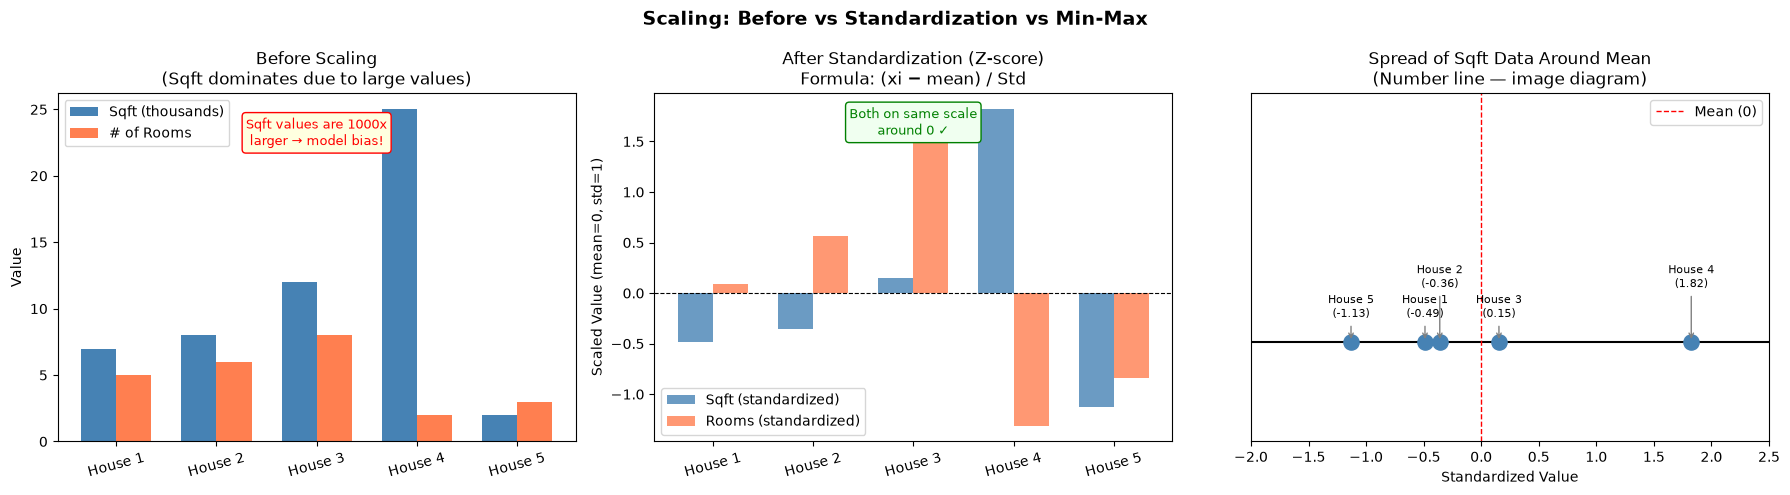

Sqft mean   = 10800
Sqft std    = 7782.03
z (7000)    = (7000 - 10800) / 7782.03 = -0.4883

Standardized Sqft values: [-0.4883 -0.3598  0.1542  1.8247 -1.1308]
Min-Max     Sqft values: [0.2174 0.2609 0.4348 1.     0.    ]


In [223]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Image lo unna exact Sqft data (thousands) and Rooms (units)
sqft   = np.array([7000, 8000, 12000, 25000, 2000])
rooms  = np.array([5, 6, 8, 2, 3])
labels = ['House 1', 'House 2', 'House 3', 'House 4', 'House 5']

# --- Standardization ---
std_scaler = StandardScaler()
sqft_std   = std_scaler.fit_transform(sqft.reshape(-1, 1)).flatten()
rooms_std  = std_scaler.fit_transform(rooms.reshape(-1, 1)).flatten()

# --- Min-Max Scaling ---
mm_scaler  = MinMaxScaler()
sqft_mm    = mm_scaler.fit_transform(sqft.reshape(-1, 1)).flatten()
rooms_mm   = mm_scaler.fit_transform(rooms.reshape(-1, 1)).flatten()

x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scaling: Before vs Standardization vs Min-Max', fontsize=14, fontweight='bold')

# ── Plot 1: Before Scaling ──
ax = axes[0]
ax.bar(x - w/2, sqft / 1000, w, label='Sqft (thousands)', color='steelblue')
ax.bar(x + w/2, rooms,       w, label='# of Rooms',       color='coral')
ax.set_title('Before Scaling\n(Sqft dominates due to large values)')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Value'); ax.legend()
ax.annotate('Sqft values are 1000x\nlarger → model bias!',
            xy=(0.5, 0.85), xycoords='axes fraction', ha='center',
            color='red', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='red'))

# ── Plot 2: After Standardization ──
ax = axes[1]
ax.bar(x - w/2, sqft_std,  w, label='Sqft (standardized)',  color='steelblue', alpha=0.8)
ax.bar(x + w/2, rooms_std, w, label='Rooms (standardized)', color='coral',     alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('After Standardization (Z-score)\nFormula: (xi − mean) / Std')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Scaled Value (mean=0, std=1)'); ax.legend()
ax.annotate('Both on same scale\naround 0 ✓',
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            color='green', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='honeydew', ec='green'))

# ── Plot 3: Spread on Number Line (Standardized Sqft) ──
ax = axes[2]
ax.axhline(0, color='black', linewidth=1.5)
ax.scatter(sqft_std, np.zeros_like(sqft_std), s=120, color='steelblue', zorder=3)
for i, (val, lbl) in enumerate(zip(sqft_std, labels)):
    ax.annotate(f'{lbl}\n({val:.2f})', xy=(val, 0),
                xytext=(val, 0.05 + 0.06 * (i % 2)),
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=8, ha='center')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Mean (0)')
ax.set_xlim(-2, 2.5)
ax.set_ylim(-0.2, 0.5)
ax.set_title('Spread of Sqft Data Around Mean\n(Number line — image diagram)')
ax.set_xlabel('Standardized Value'); ax.legend()
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Print formula demo for first value (7000)
mean_sqft = sqft.mean()
std_sqft  = sqft.std()
z_7000    = (7000 - mean_sqft) / std_sqft
print(f"Sqft mean   = {mean_sqft:.0f}")
print(f"Sqft std    = {std_sqft:.2f}")
print(f"z (7000)    = (7000 - {mean_sqft:.0f}) / {std_sqft:.2f} = {z_7000:.4f}")
print(f"\nStandardized Sqft values: {np.round(sqft_std, 4)}")
print(f"Min-Max     Sqft values: {np.round(sqft_mm, 4)}")


## Min-Max Scaling — Practical Explanation (Image Diagram)

### Formula

$$x_{scaled} = \frac{x - min}{max - min}$$

### Image lo unna example (step by step)

Image lo chupinchinatu, Sqft column values: **7000, 8000, 12000, 25000, 2000**

- **min** = 2000 (smallest value in column)
- **max** = 25000 (largest value in column)

**First value (7000) ki formula apply cheste:**

$$x_{scaled} = \frac{7000 - 2000}{25000 - 2000} = \frac{5000}{23000} \approx 0.217$$

### Prathi line ardham

| Step | Calculation | Meaning |
|:-----|:-----------:|:--------|
| `x - min` | 7000 - 2000 = **5000** | current value ki minimum teeseyyadam |
| `max - min` | 25000 - 2000 = **23000** | full range calculate cheyyadam |
| `5000 / 23000` | ≈ **0.217** | 0 to 1 madhya scaled value |

### All Sqft values scaled (Min-Max)

| Sqft | Scaled value |
|:----:|:------------:|
| 7000 | (7000-2000)/23000 = **0.217** |
| 8000 | (8000-2000)/23000 = **0.261** |
| 12000 | (12000-2000)/23000 = **0.435** |
| 25000 | (25000-2000)/23000 = **1.000** (max always 1) |
| 2000 | (2000-2000)/23000 = **0.000** (min always 0) |

### Key points

- **min value** → always scaled to **0**
- **max value** → always scaled to **1**
- **migilina values** → 0 and 1 madhya proportionally spread
- **Outlier problem:** oka chala pedda value (outlier) max ga untundi → migilina anni values 0 ki nalagipotai → model ki wrong signal

### Kid Analogy
- Class lo minimum marks = 20, maximum = 100
- Oka student 60 marks teeskunte scaled = (60-20)/(100-20) = 40/80 = **0.5** (exactly middle)
- Min-Max = marks ni percentage laaga 0 to 1 loki marchadam


> ⚠️ **Important Note:** Kinda unna code ni run chestunavvu — kani **code chudadam important kaadu**. **Graphs chudandi, concept nerchukandi.** Code ippudu ardham kaavadam avasaram ledu.

---

## Graph 1: Before vs After Min-Max — Bar + Line

**Choodalsindi (What to look for):**
- Blue bars = Original Sqft values (thousands lo — chala pedda)
- Red line (right axis) = same values Min-Max scaled (0 to 1 madhya)
- **Bar chala pedda, line 0-1 madhya chinna ga unnai** — same data, different scales
- **2000 sqft → 0.0** (minimum, so 0), **25000 sqft → 1.0** (maximum, so 1)
- Migatha values 0 and 1 madhya proportionally unnai

**Concept:** Min-Max = anni values ni 0-to-1 window loki compress cheyyadam. Min eppudu 0 avutundi, max eppudu 1 avutundi.

---

## Graph 2: Step-by-Step Formula Panel

**Choodalsindi (What to look for):**
- Idi oka text panel — graph kaadu
- Formula `(x - min) / (max - min)` ni first value (7000) ki step-by-step apply chesindi
- `x - min = 5000`, `max - min = 23000`, `result ≈ 0.217`
- Green bold "Result" row = final answer
- **Image lo diagram tho exact ga match avutundi**

**Concept:** Formula chudadam, numbers trace cheyyadam — idi nerchukupothe ye value kuda manually scale cheyyachu.


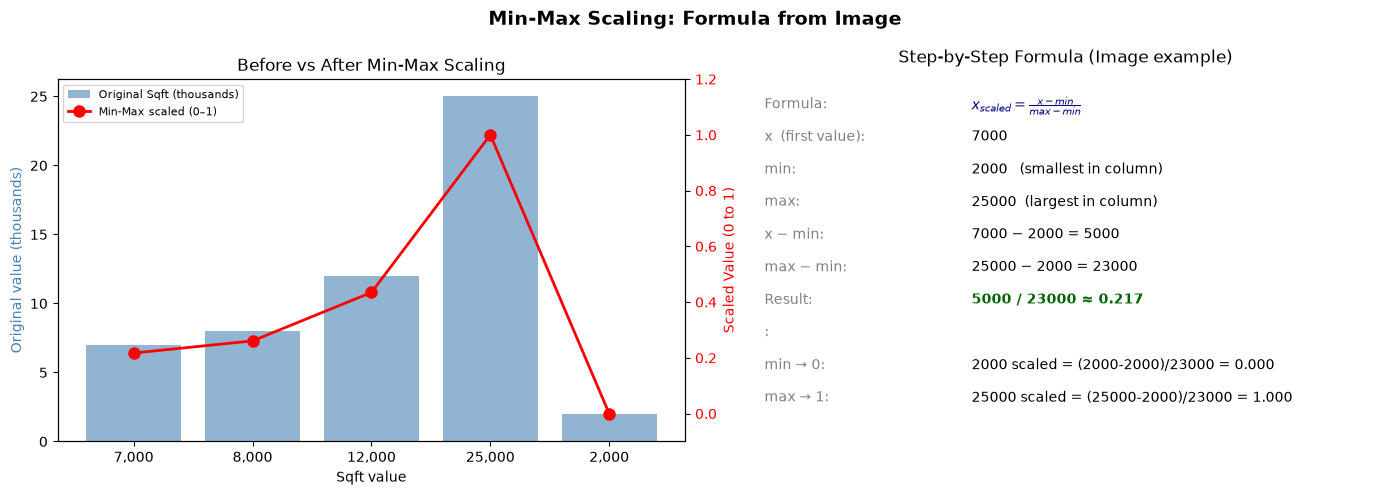

Min-Max Scaling results (image formula):
  min = 2000,  max = 25000,  range = 23000

  (7000 - 2000) / 23000 = 0.2174
  (8000 - 2000) / 23000 = 0.2609
  (12000 - 2000) / 23000 = 0.4348
  (25000 - 2000) / 23000 = 1.0000
  (2000 - 2000) / 23000 = 0.0000


In [224]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Image lo unna exact Sqft values
sqft = np.array([7000, 8000, 12000, 25000, 2000])

# Min-Max formula manually (image lo chupinchinatu)
x_min, x_max = sqft.min(), sqft.max()
sqft_mm_manual = (sqft - x_min) / (x_max - x_min)

# sklearn MinMaxScaler tho verify
mm_scaler = MinMaxScaler()
sqft_mm_sklearn = mm_scaler.fit_transform(sqft.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Min-Max Scaling: Formula from Image', fontsize=14, fontweight='bold')

labels_short = [f'{v:,}' for v in sqft]

# ── Plot 1: Before vs After Min-Max ──
ax = axes[0]
x_pos = np.arange(len(sqft))
bars = ax.bar(x_pos, sqft / 1000, color='steelblue', alpha=0.6, label='Original Sqft (thousands)')
ax2  = ax.twinx()
ax2.plot(x_pos, sqft_mm_manual, 'ro-', linewidth=2, markersize=8, label='Min-Max scaled (0–1)')
ax2.set_ylim(-0.1, 1.2)
ax2.set_ylabel('Scaled Value (0 to 1)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax.set_xticks(x_pos); ax.set_xticklabels(labels_short)
ax.set_xlabel('Sqft value'); ax.set_ylabel('Original value (thousands)', color='steelblue')
ax.set_title('Before vs After Min-Max Scaling')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# ── Plot 2: Formula step-by-step for first value (7000) ──
ax = axes[1]
ax.axis('off')
formula_steps = [
    ("Formula",          r"$x_{scaled} = \frac{x - min}{max - min}$"),
    ("x  (first value)", "7000"),
    ("min",              "2000   (smallest in column)"),
    ("max",              "25000  (largest in column)"),
    ("x − min",          "7000 − 2000 = 5000"),
    ("max − min",        "25000 − 2000 = 23000"),
    ("Result",           "5000 / 23000 ≈ 0.217"),
    ("",                 ""),
    ("min → 0",          "2000 scaled = (2000-2000)/23000 = 0.000"),
    ("max → 1",          "25000 scaled = (25000-2000)/23000 = 1.000"),
]
for row, (label, val) in enumerate(formula_steps):
    color = 'darkgreen' if 'Result' in label else ('navy' if 'Formula' in label else 'black')
    weight = 'bold' if label in ('Formula', 'Result') else 'normal'
    ax.text(0.02, 0.95 - row * 0.09, f"{label}:", fontsize=10, color='gray',
            transform=ax.transAxes, va='top')
    ax.text(0.35, 0.95 - row * 0.09, val, fontsize=10, color=color, weight=weight,
            transform=ax.transAxes, va='top')
ax.set_title('Step-by-Step Formula (Image example)', pad=12)

plt.tight_layout()
plt.show()

# Print all scaled values
print("Min-Max Scaling results (image formula):")
print(f"  min = {x_min},  max = {x_max},  range = {x_max - x_min}")
print()
for orig, scaled in zip(sqft, sqft_mm_manual):
    print(f"  ({orig} - {x_min}) / {x_max - x_min} = {scaled:.4f}")


In [225]:
import pandas as pd

# Age (units) and Salary (tens of thousands) — different scales, scaling avasaram
data = {
    "Age":    [22, 25, 30, 35, 40],
    "Salary": [25000, 50000, 75000, 100000, 150000]
}

df = pd.DataFrame(data)
print(df)


   Age  Salary
0   22   25000
1   25   50000
2   30   75000
3   35  100000
4   40  150000


### Code Explanation — Cell 83 (Line by Line)

```python
import pandas as pd
```
- `pandas` library ni import chestunnam. Idi data ni table (DataFrame) format lo handle cheyyadaniki.

---

```python
data = {
    "Age":    [22, 25, 30, 35, 40],
    "Salary": [25000, 50000, 75000, 100000, 150000]
}
```
- `data` ane dictionary create chestunnam.
- **`Age`** column: 22 to 40 — small numbers (units lo).
- **`Salary`** column: 25000 to 150000 — chala pedda numbers (tens of thousands lo).
- Idi mana **scaling problem** ki perfect example — rendu columns different scales lo unnai.

---

```python
df = pd.DataFrame(data)
```
- Dictionary ni pandas **DataFrame** (table) loki marchutunnam.
- `df` lo ippudu 5 rows, 2 columns (Age, Salary) untai.

---

```python
print(df)
```
- Raw (unscaled) data ni print chestunnam.
- Output chudadam: Age (22-40) and Salary (25000-150000) — values chala different ranges lo unnai ani confirm avutundi.

**Key takeaway:** Salary numbers Age kanna 1000x pedda ga unnai → model ki Salary more important ani anipistundi → **scaling avasaram!**


In [226]:
from sklearn.preprocessing import StandardScaler

# Age and Salary ni same scale loki teesukuvadaniki StandardScaler vadutunnam
SS = StandardScaler()
df_scaled = SS.fit_transform(df)
pd.DataFrame(df_scaled, columns=df.columns)


,Age,Salary
0,-1.286384,-1.278724
1,-0.826961,-0.697486
2,-0.061256,-0.116248
3,0.704448,0.464991
4,1.470153,1.627467


### Code Explanation — Cell 84 (Line by Line)

```python
from sklearn.preprocessing import StandardScaler
```
- sklearn library nundi `StandardScaler` ni import chestunnam.
- Idi numbers ni standardize chestundi → **mean = 0, std = 1** ga marchutundi.
- Formula: $z = \frac{x - \bar{x}}{Std}$

---

```python
SS = StandardScaler()
```
- `StandardScaler` object ni `SS` variable lo create chestunnam.
- Idi internally **mean and std** ni store chesukuntundi — training chestunantu nerchukuntundi.

---

```python
df_scaled = SS.fit_transform(df)
```
- `fit_transform` = **rendu panulu okesari** chestundi:
  - **`fit`** → `df` lo Age and Salary columns ki **mean** and **std** calculate chesi nerchukuntundi.
  - **`transform`** → aa learned values use chesi prathi value ni scale chestundi.
- Result `df_scaled` lo store avutundi — idi numpy array format lo untundi.

| Before (raw) | After StandardScaler |
|:---:|:---:|
| Age: 22, 25, 30, 35, 40 | Age: ≈ -1.41, -0.71, 0, 0.71, 1.41 |
| Salary: 25k–150k | Salary: ≈ -1.26, -0.63, 0, 0.63, 1.89 |

- Rendu columns ippudu **same scale** lo unnai — mean ≈ 0 chuttu spread.

---

```python
pd.DataFrame(df_scaled, columns=df.columns)
```
- `df_scaled` (numpy array) ni malli **pandas DataFrame** ga marchutunnam.
- `columns=df.columns` → original column names (`Age`, `Salary`) ni scaled DataFrame ki kuda apply chestunnam — output chudataniki easy.

**Key takeaway:**
- Before: Age (22-40), Salary (25k-150k) — chala different ranges.
- After: rendu columns -1.5 to +1.5 madhya — **same scale**, model ki fair input.


In [227]:
from sklearn.preprocessing import MinMaxScaler

# Age and Salary ni 0-1 range loki teesukuvadaniki MinMaxScaler vadutunnam
MM = MinMaxScaler()
df_scaled_mm = MM.fit_transform(df)
pd.DataFrame(df_scaled_mm, columns=df.columns)


,Age,Salary
0,0.000000,0.0
1,0.166667,0.2
2,0.444444,0.4
3,0.722222,0.6
4,1.000000,1.0


### Code Explanation — MinMaxScaler Cell (Line by Line)

```python
from sklearn.preprocessing import MinMaxScaler
```
- sklearn nundi `MinMaxScaler` ni import chestunnam.
- Idi values ni **0 to 1** madhya fixed range loki marchutundi.
- Formula: $x_{scaled} = \frac{x - min}{max - min}$

---

```python
MM = MinMaxScaler()
```
- `MinMaxScaler` object ni `MM` variable lo create chestunnam.
- Idi internally **min and max** values store chesukuntundi — fit chestunantu nerchukuntundi.

---

```python
df_scaled_mm = MM.fit_transform(df)
```
- `fit_transform` = **rendu panulu okesari** chestundi:
  - **`fit`** → `df` lo Age and Salary columns ki **min** and **max** values nerchukuntundi.
  - **`transform`** → formula apply chesi prathi value ni 0-1 range loki scale chestundi.
- Result `df_scaled_mm` lo store avutundi — numpy array format lo.

| Before (raw) | After MinMaxScaler |
|:---:|:---:|
| Age: 22 → 40 | Age: 0.0 → 1.0 |
| Salary: 25000 → 150000 | Salary: 0.0 → 1.0 |

- **Minimum value** eppudu **0.0** avutundi.
- **Maximum value** eppudu **1.0** avutundi.
- Migatha values 0 and 1 madhya proportionally spread avutai.

---

```python
pd.DataFrame(df_scaled_mm, columns=df.columns)
```
- `df_scaled_mm` (numpy array) ni pandas **DataFrame** ga marchutunnam.
- `columns=df.columns` → original column names (`Age`, `Salary`) ni scaled output ki kuda apply chestunnam.

**StandardScaler vs MinMaxScaler comparison:**

| Feature | StandardScaler | MinMaxScaler |
|:--------|:-------------:|:------------:|
| Output range | mean=0, std=1 (roughly -3 to +3) | **0 to 1** (fixed) |
| Min always | — | **0** |
| Max always | — | **1** |
| Outlier effect | Moderate | **High** (outlier max ga untundi → others 0 ki nalagipotai) |
| Best for | Most ML models (default) | Neural Networks, image pixels |

**Key takeaway:** StandardScaler vs MinMaxScaler — same data, different scale. Correct scaler choose cheyyadam problem type meeda depend avutundi.


# ============================================================

# SECTION 2

# Basic Preprocessing Reference (Data.csv)

Ee section lo oka simple dataset (Data.csv) tho basic preprocessing steps demonstrate chestham — Section 1 lo nerchukuna concepts apply chestham.

## Importing the libraries

### Why We Import These Libraries (Detailed)

- `numpy` enduku?
  Numpy fast ga numbers meeda work chestundi. ML lo data mostly numbers untayi, kabatti calculations fast ga jaragali.
- `pandas` enduku?
  CSV file ni table laga easy ga read cheyyali ante pandas best. Rows, columns select cheyyadam chala easy.
- `matplotlib` enduku?
  I notebook lo direct ga graphs ekkuva use cheyyakapoyina, data ni visual ga chudali ante idi helpful. Real projects lo patterns and outliers chudataniki use avutundi.

Simple ga: tools box lo right tools petti work start chestunnam.

In [228]:
# Step 1: Numerical calculations kosam numpy library ni import chestunnam.
import numpy as np
# Step 2: Graphs/plots draw cheyyadaniki matplotlib module ni import chestunnam.
import matplotlib.pyplot as plt
# Step 3: Dataset ni read and handle cheyyadaniki pandas library ni import chestunnam.
import pandas as pd

## Importing the dataset

### Why We Load Dataset and Split into X, y

- Dataset load enduku?
  Model ki nerpinchadaniki first data kavali. `Data.csv` ane file lo mana examples untayi.
- `X` (features) and `y` (target) separate enduku?
  ML model logic: **inputs** (X) ivvali, **output** (y) predict cheyyali.
  Example: country, age, salary -> purchased or not.
- Last column ni `y` ga enduku tiskunnam?
  Chala datasets lo final column result/label untundi. Anduke standard ga last column target ga tiskuntam.

Simple ga: question paper (X) and answer key (y) separate chestunnam.

### Features vs Independent vs Dependent Variables

- **Feature ante enti?**
  Feature ante model ki ichhe oka information column.
  Example: Age, Salary, Country.
  Prati column oka clue laanti di.

- **Independent Variables (X) ante enti?**
  Model ni guide cheyyadaniki manam input ga iche anni features ni kalipi `X` antam.
  Dinni predictors/input variables ani kuda antaru.
  Ee values result ni influence chestayi.

- **Dependent Variable (y) ante enti?**
  Manam predict cheyyali anukune final result ni `y` antam.
  Dinni target/output/label ani kuda antaru.
  Idi `X` meeda depend avuthundi, anduke dependent variable.

- **Simple Example (Job Selection style)**
  - Features: Aptitude Score, Communication Score, Experience Years
  - Independent Variables (X): paina 3 columns
  - Dependent Variable (y): Selected (Yes/No)

- **Real Meaning in this notebook**
  - `X = dataset.iloc[:, :-1].values` -> last column kakunda migatha columns anni inputs.
  - `y = dataset.iloc[:, -1].values` -> last column target result.

Simple ga: `X` questions, `y` answer.
Model pani: `X` chusi `y` predict cheyyadam.

In [229]:
# Step 4: 'Data.csv' file nundi complete dataset ni DataFrame lo load chestunnam.
dataset = pd.read_csv('Data.csv')
# Step 5: Last column ni vadilesi migilina columns anni features (X) ga tiskuntunnam.
X = dataset.iloc[:, :-1].values
# Step 6: Last column ni target/dependent variable (y) ga store chestunnam.
y = dataset.iloc[:, -1].values

In [230]:
# Step 7: Features matrix (X) current state ni check cheyyadaniki print chestunnam.
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [231]:
# Step 8: Target vector (y) values correct ga vachaya ani verify cheyyadaniki print chestunnam.
print(y)

<ArrowStringArray>
['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
Length: 10, dtype: str


## Taking care of missing data

### Why We Handle Missing Data

- Missing values problem enti?
  Konni rows lo age/salary empty untayi. Model ki empty value ardham kaadu.
- Mean strategy enduku?
  Numeric columns ki average value reasonable fill. Data pattern ni complete ga spoil cheyyakunda fill chestundi.
- `fit` and `transform` difference enti?
  `fit` = average value nerchukuntundi.
  `transform` = aa average ni missing places lo fill chestundi.
- 1:3 columns enduku?
  Ee dataset structure prakaram missing numeric values aa columns lo unnayi.

Simple ga: notebook lo blank spaces ni sensible words tho fill chesinattu.

In [232]:
# Step 9: Missing values fill cheyyadaniki sklearn nundi SimpleImputer ni import chestunnam.
from sklearn.impute import SimpleImputer as si
# Step 10: NaN values ni mean tho replace cheyyadaniki imputer object create chestunnam.
imputer = si(missing_values=np.nan, strategy='mean')
# Step 11: Column index 1 to 2 data meeda mean values learn cheyyadaniki fit chestunnam.
imputer.fit(X[:, 1:3])
# Step 12: Learned mean values use chesi missing places ni fill chestunnam.
X[:, 1:3] = imputer.transform(X[:, 1:3])

In [233]:
# Step 13: Missing data handle ayyaka updated features (X) ni print chesi check chestunnam.
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


## Encoding categorical data

### Encoding Topics in Correct Learning Order

#### 1) What is Category and Categorical Data?
- **Category** ante oka group name or label.
- Example: `France`, `Spain`, `Germany` each one is a category.
- `Yes`, `No` kuda categories.

- **Categorical data** ante text/label form lo unna data.
- Direct ga math cheyyalem, kabatti model ki before processing convert cheyyali.

In our notebook:
1. `Country` column in `X` is categorical (France, Spain, Germany).
2. `Purchased` column in `y` is categorical (Yes, No).

#### 2) Why Encoding is Needed
- ML models mostly numeric calculations chestayi.
- Text values ni model direct ga understand cheyyadu.
- So, text categories ni numbers ga marchadam mandatory.

#### 3) What is One-Hot Encoding?
- One-Hot Encoding ante oka categorical column ni multiple binary (0/1) columns ga split cheyyadam.
- Prati category ki oka separate column untundi.
- Row lo unna category ki `1`, migatha categories ki `0` untayi.

Example (`Country`):
- France -> [1, 0, 0]
- Spain -> [0, 1, 0]
- Germany -> [0, 0, 1]

Why useful?
- Artificial ranking problem avoid avuthundi.
- France=0, Spain=1, Germany=2 ani direct numbers iste model wrong order ni assume cheyyachu.

#### 4) Encoding for Independent Variables (`X`)
- `Country` laanti input categories ki mostly **One-Hot Encoding** use chestam.
- Enduku?
  France=0, Spain=1, Germany=2 ani direct numbers iste model wrong order assume cheyyachu.
- One-hot lo separate columns create avuthayi:
  - France -> [1, 0, 0]
  - Spain -> [0, 1, 0]
  - Germany -> [0, 0, 1]

#### 5) Why `X = np.array(ct.fit_transform(X))`?
- `ct.fit_transform(X)` output numpy-like structure or sparse matrix laga ravachu (encoder settings batti).
- `np.array(...)` valla output ni plain NumPy array format lo stabilize chestam.
- Next preprocessing steps (`train_test_split`, scaling, slicing, printing) consistent ga easy ga work avvadaniki idi help chestundi.
- Simple ga: data ni one standard shape/type lo petti pipeline smooth ga run avvadam kosam.

#### 6) What is LabelEncoder?
- LabelEncoder ane tool text labels ni numeric labels ga convert chestundi.
- Example: `No` -> 0, `Yes` -> 1.
- Idi mostly target/dependent variable (`y`) ki use chestam, especially binary classes unnapudu.

#### 7) Why mostly LabelEncoder is used for dependent variable (`y`)?
- `y` usually final output label kabatti single column lo untundi (Yes/No, Pass/Fail, Spam/Not Spam).
- Ee label ni numeric ga marchadam chalu; class order meaning create cheyyalsina avasaram usually undadu.
- `X` lo categories ki direct 0,1,2 petthe artificial order problem vastundi, kabatti akkada One-Hot safer.
- Example:
  - `y`: Yes/No -> `1/0` (safe)
  - `X` Country: France/Spain/Germany -> 0/1/2 (unsafe), One-Hot better.
- Exception: `X` lo real order unte (Small < Medium < Large), appudu ordinal style encoding use cheyyachu.

#### 8) Encoding for Dependent Variable (`y`)
- `Purchased` laanti target binary values ki **Label Encoding** saripothundi.
- **LabelEncoder enduku use chestam?**
  Model ki final target text (`Yes`/`No`) direct ga ivvakunda numeric labels (`1`/`0`) ga marchadaniki.
- Binary target lo idi simple and correct mapping istundi.
- Example:
  - No -> 0
  - Yes -> 1

#### 9) Quick Rule
1. Input feature category order lekapothe -> One-Hot.
2. Target binary aithe -> Label Encoding enough.
3. Goal: model confusion lekunda clean numeric representation ivvadam.

### Encoding the Independent Variable

In [234]:
# Step 14: Specific columns ki different transforms apply cheyyadaniki ColumnTransformer ni import chestunnam.
from sklearn.compose import ColumnTransformer
# Step 15: Categorical text ni binary columns ga marchadaniki OneHotEncoder ni import chestunnam.
from sklearn.preprocessing import OneHotEncoder
# Step 16: 0th column ki one-hot encoding apply chesi, migatha columns ni alane pass-through cheyyadaniki transformer set chestunnam.
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
# Step 17: Transformer output ni fit-transform chesi, next steps lo stable ga use cheyyadaniki plain NumPy array ga convert chestunnam.
X = np.array(ct.fit_transform(X))

In [235]:
# Step 18: Independent variable encoding tarvata X ela undho print chesi verify chestunnam.
print(X)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 38.77777777777778 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


### Encoding the Dependent Variable

In [236]:
# Step 19: Target labels ni number format lo ki marchadaniki LabelEncoder ni import chestunnam.
from sklearn.preprocessing import LabelEncoder
# Step 20: Label encoding operation kosam encoder object create chestunnam (text target ni model-friendly numbers ga marchadaniki).
le = LabelEncoder()
# Step 21: y lo unna class names ni integer labels ga convert chestunnam (example: No->0, Yes->1).
y = le.fit_transform(y)

In [237]:
# Step 22: Dependent variable encoding result ni print chesi confirm chestunnam.
print(y)

[0 1 0 0 1 1 0 1 0 1]


## Splitting the dataset into the Training set and Test set

### Why We Split into Train and Test

- Train set enduku?
  Model ni nerpinchadaniki.
- Test set enduku?
  Model real ga new data meeda ela perform chestundo check cheyyadaniki.

Simple ga: tuition class (train) and final exam (test) separate chestunnam.

### `test_size` ante enti? (detail)

- Total data lo entha % test ki pettalo cheppe value.
- `test_size=0.2` ante 20% test ki, migilina 80% train ki.
- Value 0 and 1 madhya untundi (0.2 = 20%, 0.25 = 25%).
- Integer kuda ivvachu: `test_size=50` ante exactly 50 rows test ki.

Example:
- Total 100 rows, `test_size=0.2` -> Train = 80 rows, Test = 20 rows.
- Total 100 rows, `test_size=0.3` -> Train = 70 rows, Test = 30 rows.

Endhuku 0.2 (20%) common?
- Test chala chinnaga unte (e.g. 5%) -> exam score meeda nammakam thakkuva (too few samples).
- Test chala peddaga unte (e.g. 50%) -> model ki nerchukovadaniki data thakkuva.
- 20% balanced choice: enough train + enough test.

### `random_state` ante enti? (detail)

- `train_test_split` rows ni randomly shuffle chesi split chestundi.
- `random_state` aa randomness ki oka **fixed seed** istundi.
- Same seed pettinappudu shuffle same order lo jarigi, **same split** malli malli vastundi (reproducibility).

`random_state` LEKUNTE emavutundi?
- Prathi run ki different rows train/test ki veltayi.
- Accuracy koncham up/down avtundi, results compare cheyyadam kashtam.

`random_state` PETTINAPPUDU:
- `random_state=1` today run chesina, repu run chesina -> exactly same X_train, X_test.
- Team lo evaru run chesina same result -> debugging and comparison easy.

Example:
```python
# random_state lekunda -> prathi sari veru split
train_test_split(X, y, test_size=0.2)

# random_state=1 -> anni run lalo same split
train_test_split(X, y, test_size=0.2, random_state=1)

# random_state=42 -> idi kuda fixed, kani 1 kanna veru split
train_test_split(X, y, test_size=0.2, random_state=42)
```

Gurthu pettuko:
- `random_state` value (1 aina, 42 aina) result quality ni marchadu; adi just "which fixed shuffle" ane point.
- Main goal: reproducibility (same result malli ravadam).

Simple ga: cards ni shuffle cheyyadam laantidi. `random_state` ante "same shuffle pattern" ni lock cheyyadam -> prathi sari same order.

In [238]:
# Step 23: Dataset ni train and test sets ga split cheyyadaniki function ni import chestunnam.
from sklearn.model_selection import train_test_split
# Step 24: 80% data training ki, 20% data testing ki split chestunnam; random_state fixed kabatti same split repeat avutundi.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [239]:
# Step 25: Training features ela unnayo choodadaniki X_train ni print chestunnam.
print(X_train)

[[0.0 0.0 1.0 38.77777777777778 52000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 35.0 58000.0]]


In [240]:
# Step 26: Testing features ela unnayo verify cheyyadaniki X_test ni print chestunnam.
print(X_test)

[[0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [241]:
# Step 27: Training target labels ni check cheyyadaniki y_train ni print chestunnam.
print(y_train)

[0 1 0 0 1 1 0 1]


In [242]:
# Step 28: Testing target labels ni check cheyyadaniki y_test ni print chestunnam.
print(y_test)

[0 1]


## Feature Scaling

### Why We Do Feature Scaling

- Scaling problem enti?
  Age 20-50 range lo untundi, salary 30000-90000 range lo untundi. Pedda number column model decision ni dominate cheyyachu.
- StandardScaler enduku?
  Features ni similar scale ki teesukostundi (mean around 0, std around 1).
  Formula concept: z = (x - mean) / std.
- `fit_transform(X_train)` and `transform(X_test)` enduku?
  Train data nundi mathrame mean/std nerchukovali.
  Test data ni ade rules tho transform cheyyali.
  Test data nundi learn chesthe data leakage jaruguthundi.

Simple ga: oka player cm lo, inko player inches lo measure chesthe compare kashtam. First same unit lo ki marchi compare chestunnam.

### Why Feature Scaling AFTER Train-Test Split?

- Test set ante future/new data laanti di. Real world lo aa data mundu manaki teliyadu.
- Scaling ki kavalsina mean and std **only train data** nundi nerchukovali.
- Split **before** scaling chesthe, test data values scaler nerchukune step lo kalavavu.
- Split **after** scaling chesthe, test data mean/std kuda scaler lo kalisipothundi -> **data leakage**.
- Data leakage valla test score falsely high vastundi, kani real new data meeda model fail avvachu.

Correct order:
1. Split cheyyi (train, test).
2. `sc.fit_transform(X_train)` -> train nundi mean/std nerchuko + scale.
3. `sc.transform(X_test)` -> ade learned values tho test ni scale cheyyi.

Simple ga: exam ki mundu question paper chudakunda prepare avvali. Scaler ki test data mundu chupisthe adi "cheating" (leakage) laanti di.

### Standardisation vs Normalisation - Eppudu Edi Vadali?

**Standardisation (StandardScaler)**
- Formula: z = (x - mean) / std.
- Result: mean around 0, std around 1. Range fix kaadu (values negative kuda ravachu).
- Eppudu vadali?
  - Data roughly **normal (bell curve)** ga unnappudu.
  - Outliers unnappudu (normalisation kanna better handle chestundi).
  - Algorithms: Linear/Logistic Regression, SVM, PCA, KNN, Neural Networks - most common default.

**Normalisation (MinMaxScaler)**
- Formula: x_scaled = (x - min) / (max - min).
- Result: anni values **0 and 1 madhya** (fixed range).
- Eppudu vadali?
  - Data distribution normal kaadu (unknown/skewed) unnappudu.
  - Fixed bounded range [0,1] kavali anapp (e.g. image pixels 0-255 -> 0-1).
  - Algorithms: Neural Networks (bounded input), KNN, distance-based models.
- Jagratha: outliers unte min/max ni cheddaga effect chestai (adi bad).

**Quick Rule:**
- Confusion unte -> **Standardisation** (safe default, ekkuva cases lo pani chestundi).
- Bounded [0,1] range kavali OR data normal kaadu -> **Normalisation**.
- Tree-based models (Decision Tree, Random Forest, XGBoost) ki scaling **avasaram ledu**.

Simple ga:
- Standardisation = "average nunchi entha door" ani cheppadam (center 0).
- Normalisation = "0 to 100 marks percentage laaga" 0-1 loki teesukuravadam.

### Ee Techniques Enduku Apply Chestam? (kid ki cheppinatlu)

Oohinchuko: nuvvu class teacher vi. Oka student Ravi undi.
- Ravi height **150 cm**.
- Ravi weight **45 kg**.

Ippudu neeku oka "friend robot" (model) undi. Aa robot students ni compare cheyyadaniki numbers chusthundi. Kaani robot ki oka chinna problem undi: **pedda number ekkuva important** ani anukuntundi.

- Height number = 150 (pedda).
- Weight number = 45 (chinna).

Robot ki telavadu ivi different things (cm and kg) ani. Adi anukuntundi "150 anni 45 kanna chala ekkuva, kabatti height matrame important" - idi **tappu**. Nijaniki rendu equal ga important.

**Ee problem ni fix cheyyadaniki manam scaling techniques vadatam.** Manam anni numbers ni oka **same/fair scale** loki marchi, robot ki cheptam: "ee rendu columns ni equal ga chudu."

**Enduku idi mukhyam? (3 chinna reasons)**
1. **Fairness:** Pedda number unna column (salary laaga) chinna number column (age laaga) ni dominate cheyyakunda apthundi. Anni features ki equal chance.
2. **Speed:** Chala models (gradient descent vadedi) same-scale data meeda **fast** ga nerchukuntai. Different scales unte slow and confusing.
3. **Accuracy:** Distance calculate chese models (KNN, SVM) ki scaling lekapothe answers tappu vastai, endukante pedda number distance ni control chestundi.

**Ilaanti daily-life example:**
Race petta: oka pillodini **kilometers** lo, inko pillodini **meters** lo speed cheppi "evadu fast?" ani adigithe confuse avtam. First rendu ni **same unit** loki marchi, aa tarvata compare chestam. Scaling chesedi exactly ade - anni ni same "language/unit" loki marchi model ki compare cheyyadam easy chestundi.

**Chinna gurthu (summary):**
- Scaling = numbers ni fair ga, same size loki marchadam.
- Standardisation and Normalisation = ade pani chese rendu different methods.
- Idi model ki nerchukovadam **easy, fast, and fair** chestundi.

In [243]:
# Step 29: Feature values ni same scale lo ki teesukoradaniki StandardScaler ni import chestunnam.
from sklearn.preprocessing import StandardScaler
# Step 30: Scaling operation kosam scaler object create chestunnam.
sc = StandardScaler()
# Step 31: Training data meeda mean and std learn chesi X_train ni scale chestunnam.
X_train[:,3:] = sc.fit_transform(X_train[:,3:])
# Step 32: Ade learned scaling rules ni X_test ki apply chestunnam (data leakage avoid avuthundi).
X_test[:,3:] = sc.transform(X_test[:,3:])

### Feature Scaling Code Explanation (Line by Line)

Ee code lo `X_train[:,3:]` and `X_test[:,3:]` ane slicing use chesam. Adi enduku ane point chala important.

Mundu oka gurthu: One-Hot Encoding tarvata mana `X` lo modati konni columns dummy (0/1) columns ayyayi.
- Column 0, 1, 2 -> Country one-hot columns (France, Spain, Germany laanti 0/1 values).
- Column 3 -> Age.
- Column 4 -> Salary.

#### `[:, 3:]` ante enti?
- NumPy slicing format: `[rows, columns]`.
- `:` ante anni rows teesuko.
- `3:` ante column index 3 nunchi last varaku teesuko (0,1,2 vadilesi).
- Ante manam Age and Salary columns matrame select chestunnam.

#### Line 1: `from sklearn.preprocessing import StandardScaler`
- StandardScaler tool import chestunnam. Idi numbers ni standardise chestundi (mean 0, std 1).

#### Line 2: `sc = StandardScaler()`
- Oka scaler object (`sc`) create chestunnam. Idi mean and std store chesukoni scaling chestundi.

#### Line 3: `X_train[:,3:] = sc.fit_transform(X_train[:,3:])`
- `fit_transform` rendu panulu chestundi:
  - fit -> X_train lo Age and Salary columns nunchi mean and std nerchukuntundi.
  - transform -> aa learned values tho aa columns ni scale chestundi.
- Result ni malli ade columns lo (`X_train[:,3:]`) tirigi pettestunnam.
- Dummy columns (0,1,2) ni touch cheyyatam ledu, avi already 0/1 kabatti scaling avasaram ledu.

#### Line 4: `X_test[:,3:] = sc.transform(X_test[:,3:])`
- Ikkada transform only (fit kaadu).
- X_train nunchi already nerchukunna same mean/std ni X_test ki apply chestunnam.
- Idi data leakage avoid chestundi (test data nunchi kotha mean/std nerchukokudadu).

#### Enduku `[:, 3:]` full `X_train` kaadu?
- One-hot dummy columns (0,1,2) already 0/1 values.
- Vaatini scale chesthe:
  - Vaati meaning (which category) paadi potundi.
  - 0/1 values negative decimals ga maratayi, interpret cheyyadam kashtam.
- Anduke only real numeric columns (Age, Salary) ni scale chestunnam, dummy columns ni alane vadilestunnam.

#### Chinna summary
- `[:, 3:]` ante "dummy columns vadilesi, real numbers (Age, Salary) matrame scale cheyyi."
- `fit_transform` train meeda, `transform` test meeda -> fair and leakage-free scaling.

In [244]:
# Step 33: Scaled training features ni print chesi centered values vachaya ani check chestunnam.
print(X_train)

[[0.0 0.0 1.0 -0.19159184384578545 -1.0781259408412425]
 [0.0 1.0 0.0 -0.014117293757057777 -0.07013167641635372]
 [1.0 0.0 0.0 0.566708506533324 0.633562432710455]
 [0.0 0.0 1.0 -0.30453019390224867 -0.30786617274297867]
 [0.0 0.0 1.0 -1.9018011447007988 -1.420463615551582]
 [1.0 0.0 0.0 1.1475343068237058 1.232653363453549]
 [0.0 1.0 0.0 1.4379472069688968 1.5749910381638885]
 [1.0 0.0 0.0 -0.7401495441200351 -0.5646194287757332]]


In [245]:
# Step 34: Scaled testing features ni print chesi final preprocessing output ni verify chestunnam.
print(X_test)

[[0.0 1.0 0.0 -1.4661817944830124 -0.9069571034860727]
 [1.0 0.0 0.0 -0.44973664397484414 0.2056403393225306]]


## Kid-Style Architecture and Flow (Data Preprocessing)

Manam ikada raw data ni clean chesi, machine learning ki ready chestunnam.
Simple ga idi "school ki velladaniki child ni ready cheyyadam" laanti process.

### End-to-End Flow

```mermaid
flowchart TD
    A[Raw CSV Data] --> B[Load into Pandas]
    B --> C[Split X and y]
    C --> D[Handle Missing Values]
    D --> E[Encode Categorical Values]
    E --> F[Train Test Split]
    F --> G[Feature Scaling]
    G --> H[Clean ML Ready Data]
```

### Architecture Simple Explanation
1. **Input Layer**: `Data.csv` nundi raw data vasthundi.
2. **Cleaning Layer**: missing values fill chestham.
3. **Encoding Layer**: text values ni numbers ga marchestham.
4. **Split Layer**: train set and test set create chestham.
5. **Scaling Layer**: feature values same scale lo ki teesukostham.
6. **Output Layer**: model training ki ready data.

### Kid Analogy
- Raw data = unwashed vegetables
- Cleaning = wash + cut
- Encoding = labels pettadam
- Split = practice vs exam papers
- Scaling = all rulers ni same unit lo set cheyyadam